<div class='bar_title'></div>

*Data Driven Decisions in Practice (D3IP): Urban Analytics*

# 2. Handling Spatial Data in Python

__Prof. Dr. Gunther Gust__ <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

In this lecture, we learn how to load, manipulate, and visualize spatial data. We use `geopandas` — a Pandas extension that adds a `geometry` column and spatial operations to the familiar `DataFrame`.

## Content

- PART a) Spatial Data Types and Plotting
- Part b) Performing Spatial Computations
- Part c) Kernel Density Estimation (KDE)

*Credits: Much of the material is taken from [Arribas-Bel, Geographic Data Science](https://darribas.org/gds_course/content/home.html#)*

# PART a) Spatial Data Types and Plotting

## Loading spatial data

In [5]:
import numpy as np
import geopandas
import osmnx
import contextily as cx
import pyproj

import matplotlib.pyplot as plt
import mapclassify
import seaborn
import geodatasets

import warnings
warnings.filterwarnings('ignore')

## Polygons (e.g. Cities)

*This dataset is derived from {cite}`arribas2019building`, which proposes a machine learning algorithm to delineate city boundaries.*

Spatial data can be stored in many file formats. We use `geopandas.read_file()` to load them. 
Common formats include GeoPackage (`.gpkg`), GeoJSON (`.geojson`), and Shapefile (`.shp`).

In [6]:
cities = geopandas.read_file("https://raw.githubusercontent.com/GuntherGust/sc_gdsa_data/main/spanish_cities.gpkg")
cities.head()

,city_id,n_buildings,geometry
0,ci000,2348,"POLYGON ((385390.071 4202949.446, 384488.697 4..."
1,ci001,2741,"POLYGON ((214893.033 4579137.558, 215258.185 4..."
2,ci002,5472,"POLYGON ((690674.281 4182188.538, 691047.526 4..."
3,ci003,14608,"POLYGON ((513378.282 4072327.639, 513408.853 4..."
4,ci004,2324,"POLYGON ((206989.081 4129478.031, 207275.702 4..."


A `GeoDataFrame` is like a regular `DataFrame`, but with a `geometry` column. We can plot it directly:

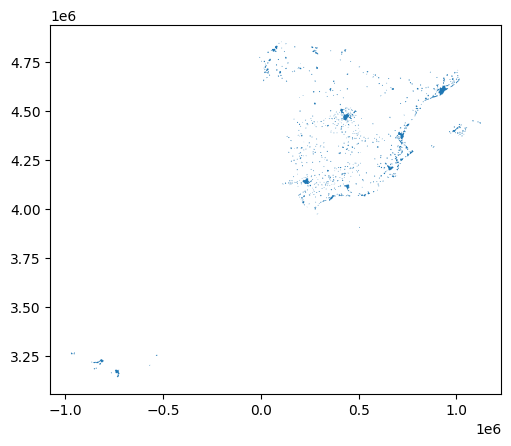

In [7]:
cities.plot();

## Lines (e.g. Streets)

*This dataset comes from a project called "Las calles de las mujeres", a community-driven initiative exploring the extent to which streets are named after women.*

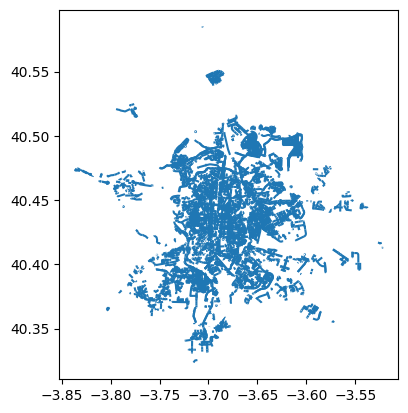

In [8]:
streets = geopandas.read_file("https://raw.githubusercontent.com/GuntherGust/sc_gdsa_data/main/final_tile.geojson")
streets.plot();

## Points (e.g. Bars)

The final dataset is a set of points demarcating the location of bars in Madrid, retrieved from OpenStreetMap via `osmnx`.

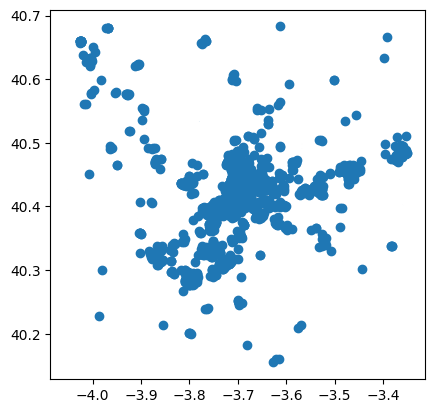

In [9]:
pois = osmnx.features_from_address(
    "Madrid, Spain", dist = 30000, tags={"amenity": "bar"}
)
pois.plot();

## Composing multi-layer maps

Layers are overlaid by passing the same `ax` to each `.plot()` call. **All datasets must be in the same CRS before combining.**

For this section, let's select only Madrid from the `cities` table and convert it to lat/lon so it's aligned with the `streets` and `POI`s layers:

In [10]:
mad = cities.loc[[12], :].to_crs(epsg=4326)
mad

,city_id,n_buildings,geometry
12,ci012,193714,"POLYGON ((-3.90016 40.30421, -3.90019 40.30457..."


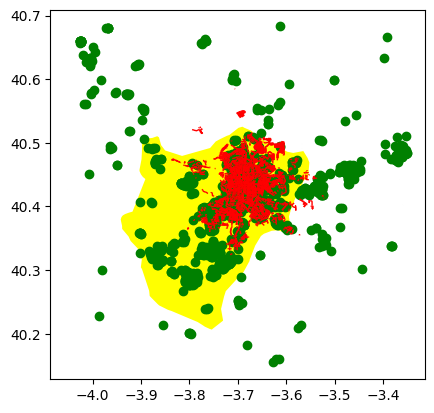

In [11]:
# Default: functional but not pretty
f, ax = plt.subplots(1)
mad.plot(ax=ax, color='yellow')
streets.plot(ax=ax, color='red', linewidth=1)
pois.plot(ax=ax, color='green')
plt.show()

## Styling plots

Default plots are functional but rarely publication-ready. 
Rather than learning every styling parameter by heart, it is more useful to see what a polished map looks like 
and then use an AI assistant or the [matplotlib documentation](https://matplotlib.org/stable/) to customize plots as needed.


And here is the multi-layer map from above, polished with a basemap, better colors, and proper labeling:

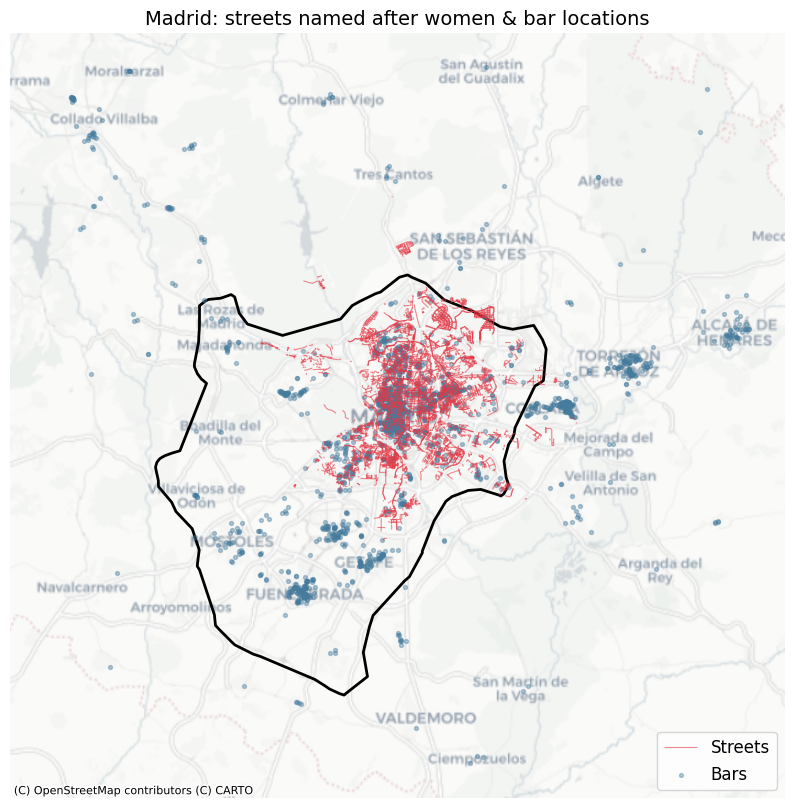

In [12]:
# Polished version
f, ax = plt.subplots(1, figsize=(10, 10))

# City boundary
mad.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2)

# Streets named after women
streets.plot(ax=ax, color='#e63946', linewidth=0.8, alpha=0.6, label='Streets')

# Bars
pois.plot(ax=ax, color='#457b9d', markersize=8, alpha=0.4, label='Bars')

# Basemap
cx.add_basemap(ax, crs=mad.crs, source=cx.providers.CartoDB.Positron)

ax.set_title('Madrid: streets named after women & bar locations', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.set_axis_off();

The key styling parameters used here are:
- `figsize` — figure dimensions
- `facecolor`, `edgecolor`, `color` — fill and border colors
- `linewidth`, `markersize` — size of lines and points
- `alpha` — transparency (0 = invisible, 1 = opaque)
- `set_axis_off()` — removes the axis frame
- `cx.add_basemap()` — adds a background map for geographic context

You do not need to memorize these. When you need to style a map, describe what you want to an AI assistant or consult the documentation.

When combining layers, **all datasets must be in the same CRS** — otherwise features appear in the wrong location.

## Coordinate Reference Systems (CRS)

- The Earth is a sphere; a map is flat — projecting one onto the other always distorts something
- Every projection preserves some properties (area, shape, distance) at the cost of others
- Familiar distortion: Greenland looks as large as Africa on a Mercator map — Africa is 14× larger

Every projection distorts at least one of:
- **Area** — how large something is
- **Shape** — how something looks
- **Distance** — how far apart points are
- **Direction** — which way something lies

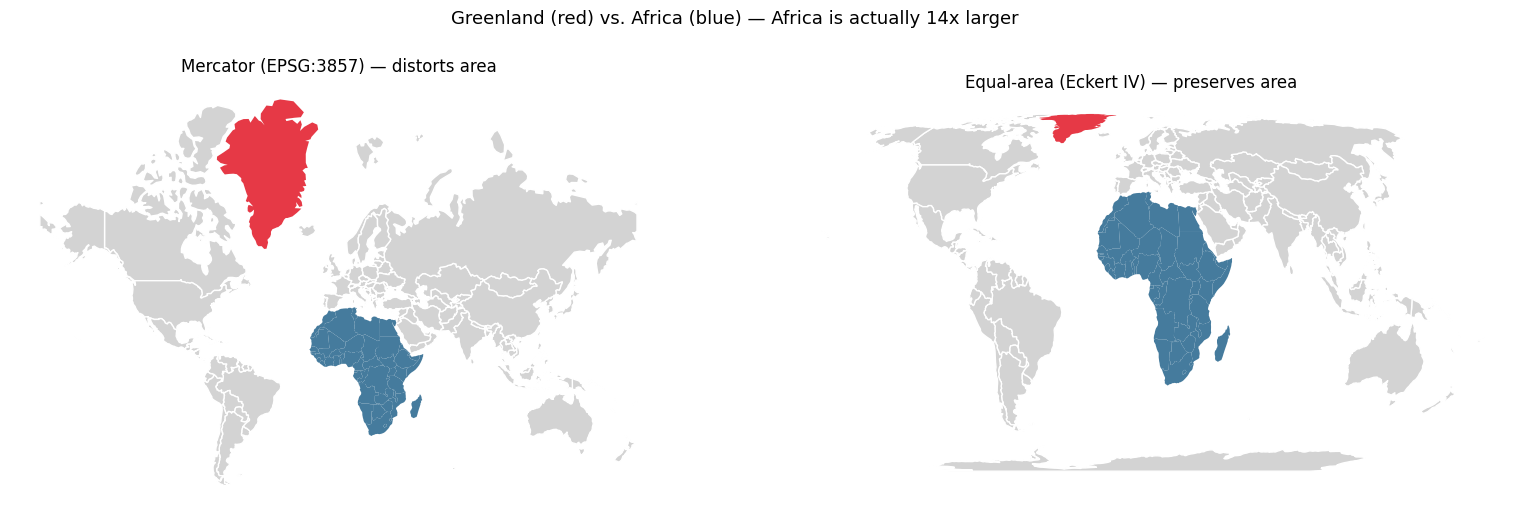

In [13]:
# Load world countries
world = geopandas.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)
greenland = world[world['NAME'] == 'Greenland']
africa = world[world['CONTINENT'] == 'Africa']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mercator projection: distorts area
# Clip to avoid extreme polar distortion
from shapely.geometry import box
clip_region = geopandas.GeoDataFrame(geometry=[box(-180, -60, 180, 85)], crs='EPSG:4326')
world_clip = geopandas.overlay(world.to_crs('EPSG:4326'), clip_region, how='intersection')
world_clip.to_crs(epsg=3857).plot(ax=axes[0], color='lightgrey', edgecolor='white')
greenland.to_crs(epsg=3857).plot(ax=axes[0], color='#e63946')
africa.to_crs(epsg=3857).plot(ax=axes[0], color='#457b9d')
axes[0].set_title('Mercator (EPSG:3857) — distorts area', fontsize=12)
axes[0].set_axis_off()

# Equal-area projection: preserves area
world.to_crs('+proj=eck4').plot(ax=axes[1], color='lightgrey', edgecolor='white')
greenland.to_crs('+proj=eck4').plot(ax=axes[1], color='#e63946')
africa.to_crs('+proj=eck4').plot(ax=axes[1], color='#457b9d')
axes[1].set_title('Equal-area (Eckert IV) — preserves area', fontsize=12)
axes[1].set_axis_off()

plt.suptitle('Greenland (red) vs. Africa (blue) — Africa is actually 14x larger',
             fontsize=13, y=1.02)
plt.tight_layout()

### Degrees vs. meters — the practical distinction

| CRS type | Example | Unit | Use for |
|----------|---------|------|---------|
| **Degree-based** | EPSG:4326 (WGS84) | degrees | Display, GPS, data exchange |
| **Meter-based** | UTM, national grids | meters | Area, distance, buffers |

⚠️ A degree is *not* a fixed distance — at the equator ≈ 111 km, near the poles ≈ 0 km  
⚠️ `geometry.area` or `buffer(1000)` on degree-based data gives results in *degrees* — meaningless

### CRS in GeoPandas

Every `GeoDataFrame` has a `.crs` attribute that tells you which coordinate system it uses:

In [14]:
cities.crs

<Projected CRS: EPSG:25830>
Name: ETRS89 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°W and 0°W: Faroe Islands offshore; Ireland - offshore; Jan Mayen - offshore; Norway including Svalbard - offshore; Spain - mainland - onshore and offshore.
- bounds: (-6.0, 35.26, 0.01, 80.49)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Meter-based projected CRS (Spanish national grid, EPSG:25830). Use `to_crs(epsg=...)` to reproject. [EPSG:4326](https://epsg.io/4326) is the standard WGS84 lat/lon system.

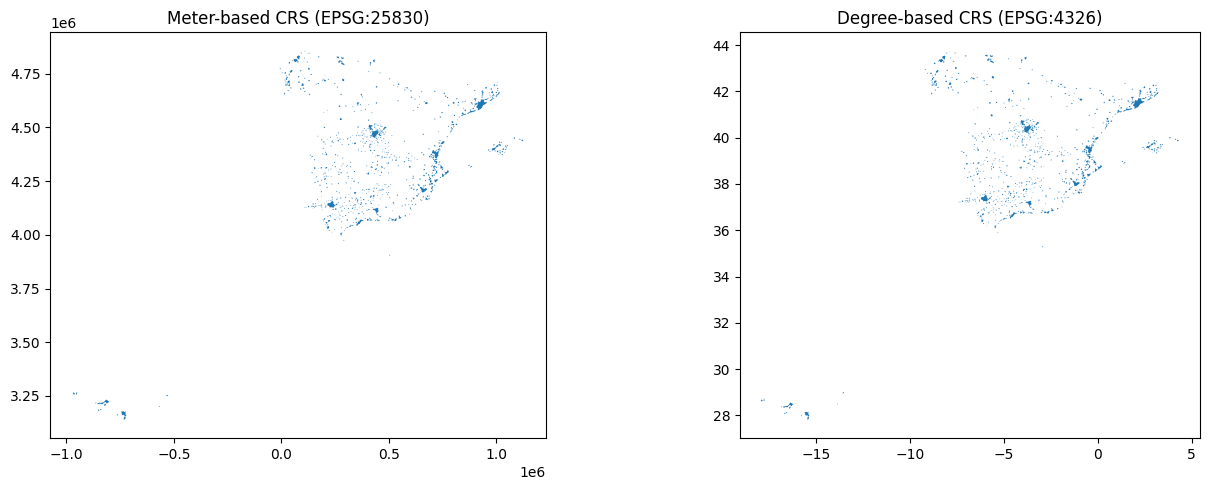

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: meter-based CRS
cities.plot(ax=axes[0])
axes[0].set_title('Meter-based CRS (EPSG:25830)')

# Reprojected: degree-based CRS
cities.to_crs(epsg=4326).plot(ax=axes[1])
axes[1].set_title('Degree-based CRS (EPSG:4326)')

plt.tight_layout()

Note how the shapes look slightly different and the axis scales change — from meters to degrees. 
**Always check the CRS before computing areas, distances, or buffers.**

## Interactive maps

Everything we have seen so far relates to static maps. These are useful for publication, to include in reports or to print. However, modern web technologies afford much more flexibility to explore spatial data interactively.

We will use the state-of-the-art Leaflet integration into `geopandas`. In this context, we can take a `GeoDataFrame` into an interactive map in one line of code:

```python
streets.explore()
```

# Part b) Performing spatial computations on `GeoDataFrames`

In this section we switch to a different city and dataset: **Chicago**, using built-in sample data from the `geodatasets` package. We will work with community area boundaries and grocery store locations to explore spatial relationships.

## Spatial Joins

A spatial join answers: ***which things are where?***

Unlike conventional joins (shared key column), the join key here is **location**:

- *How many schools are in each district?*
- *Which residents live within 500 m of a polluted site?*
- *Which community is this GPS point in?*

No shared column needed — just a shared geographic footprint.

In a spatial join, two geometry objects are merged based on their spatial relationship to one another. GeoPandas provides two spatial-join functions:
* `GeoDataFrame.sjoin()`: joins based on binary predicates (intersects, contains, etc.)
* `GeoDataFrame.sjoin_nearest()`: joins based on proximity, with the ability to set a maximum search radius.

The following is adapted from the [geopandas documentation](https://geopandas.org/en/stable/docs/user_guide/mergingdata.html).

Example: Count how many grocery stores are in each district of Chicago 

In [16]:
chicago = geopandas.read_file(geodatasets.get_path("geoda.chicago_commpop"))
groceries = geopandas.read_file(geodatasets.get_path("geoda.groceries"))

chicago = chicago[['geometry', 'community', 'POP2010']].to_crs(groceries.crs)

Extracting 'chicago_commpop/chicago_commpop.geojson' from '/home/vscode/.cache/geodatasets/chicago_commpop.zip' to '/home/vscode/.cache/geodatasets/chicago_commpop.zip.unzip'
Extracting 'grocery/chicago_sup.shp' from '/home/vscode/.cache/geodatasets/grocery.zip' to '/home/vscode/.cache/geodatasets/grocery.zip.unzip'
Extracting 'grocery/chicago_sup.dbf' from '/home/vscode/.cache/geodatasets/grocery.zip' to '/home/vscode/.cache/geodatasets/grocery.zip.unzip'
Extracting 'grocery/chicago_sup.shx' from '/home/vscode/.cache/geodatasets/grocery.zip' to '/home/vscode/.cache/geodatasets/grocery.zip.unzip'
Extracting 'grocery/chicago_sup.prj' from '/home/vscode/.cache/geodatasets/grocery.zip' to '/home/vscode/.cache/geodatasets/grocery.zip.unzip'


In [17]:
groceries.head()

,OBJECTID,Ycoord,Xcoord,Status,Address,Chain,Category,geometry
0,16,41.973266,-87.657073,OPEN,"1051 W ARGYLE ST, CHICAGO, IL. 60640",VIET HOA PLAZA,NaN,MULTIPOINT ((1168268.672 1933554.35))
1,18,41.696367,-87.681315,OPEN,"10800 S WESTERN AVE, CHICAGO, IL. 60643-3226",COUNTY FAIR FOODS,NaN,MULTIPOINT ((1162302.618 1832900.224))
2,22,41.868634,-87.638638,OPEN,"1101 S CANAL ST, CHICAGO, IL. 60607-4932",WHOLE FOODS MARKET,NaN,MULTIPOINT ((1173317.042 1895425.426))
3,23,41.877590,-87.654953,OPEN,"1101 W JACKSON BLVD, CHICAGO, IL. 60607-2905",TARGET/SUPER,new,MULTIPOINT ((1168996.475 1898801.406))
4,27,41.737696,-87.625795,OPEN,"112 W 87TH ST, CHICAGO, IL. 60620-1318",FOOD 4 LESS,NaN,MULTIPOINT ((1176991.989 1847262.423))


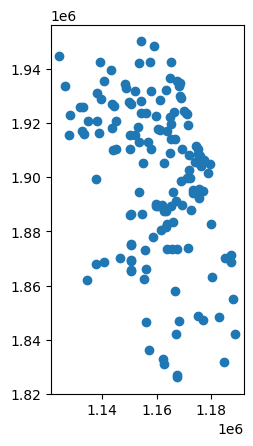

In [18]:
groceries.plot();

In [19]:
chicago.head()

,geometry,community,POP2010
0,"MULTIPOLYGON (((1181573.25 1886828.039, 118157...",DOUGLAS,18238
1,"MULTIPOLYGON (((1186289.356 1876750.733, 11862...",OAKLAND,5918
2,"MULTIPOLYGON (((1176344.998 1871187.546, 11763...",FULLER PARK,2876
3,"MULTIPOLYGON (((1182322.043 1876674.73, 118232...",GRAND BOULEVARD,21929
4,"MULTIPOLYGON (((1186289.356 1876750.733, 11862...",KENWOOD,17841


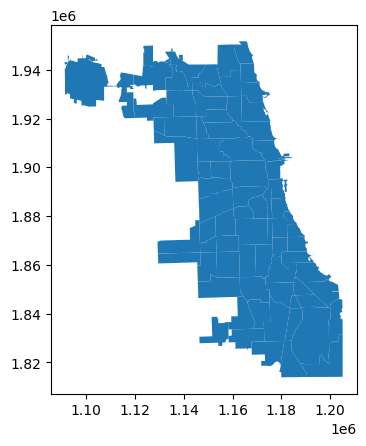

In [20]:
chicago.plot();

Perform spatial join

In [21]:
groceries_with_community = groceries.sjoin(chicago, how="left", predicate='intersects')
groceries_with_community.head()

,OBJECTID,Ycoord,Xcoord,Status,Address,Chain,Category,geometry,index_right,community,POP2010
0,16,41.973266,-87.657073,OPEN,"1051 W ARGYLE ST, CHICAGO, IL. 60640",VIET HOA PLAZA,NaN,MULTIPOINT ((1168268.672 1933554.35)),30,UPTOWN,56362
1,18,41.696367,-87.681315,OPEN,"10800 S WESTERN AVE, CHICAGO, IL. 60643-3226",COUNTY FAIR FOODS,NaN,MULTIPOINT ((1162302.618 1832900.224)),73,MORGAN PARK,22544
2,22,41.868634,-87.638638,OPEN,"1101 S CANAL ST, CHICAGO, IL. 60607-4932",WHOLE FOODS MARKET,NaN,MULTIPOINT ((1173317.042 1895425.426)),28,NEAR WEST SIDE,54881
3,23,41.877590,-87.654953,OPEN,"1101 W JACKSON BLVD, CHICAGO, IL. 60607-2905",TARGET/SUPER,new,MULTIPOINT ((1168996.475 1898801.406)),28,NEAR WEST SIDE,54881
4,27,41.737696,-87.625795,OPEN,"112 W 87TH ST, CHICAGO, IL. 60620-1318",FOOD 4 LESS,NaN,MULTIPOINT ((1176991.989 1847262.423)),39,CHATHAM,31028


**`how`** — which rows appear in the result:

| Value | Keeps | Typical use |
|-------|-------|-------------|
| `'left'` | all rows from left GDF | assign attributes to every point |
| `'right'` | all rows from right GDF | find all polygons that contain something |
| `'inner'` | matched rows only | strict filtering |

**`predicate`** — spatial relationship that counts as a match: `intersects`, `contains`, `within`, `touches`, `crosses`, `overlaps`

Complex spatial relationships combine geometric operations with joins: e.g., buffer a point into a circle, then intersect against polygons.

**Predicate** — how GeoPandas decides whether to join two geometries:

- `intersects` — geometries share any point *(most common)*
- `contains` — left geometry fully contains right
- `within` — left geometry is fully inside right
- `touches` — share boundary only, no interior overlap
- `crosses` — line crosses through a polygon
- `overlaps` — same dimension, partial overlap

Count the number of groceries in each community

In [22]:
grocery_count = groceries_with_community.groupby('community').size()
grocery_count[:10]

community
ALBANY PARK       1
ARCHER HEIGHTS    2
ARMOUR SQUARE     1
ASHBURN           1
AUBURN GRESHAM    1
AUSTIN            3
AVONDALE          2
BELMONT CRAGIN    6
BRIGHTON PARK     2
CHATHAM           3
dtype: int64

Let's create a plot to display the results:

In [23]:
#convert series into dataframe
grocery_count_df = grocery_count.reset_index(name="size")

#add results as new column to chicago geodataframe
community_groceries = chicago.merge(grocery_count_df, on="community", how="left")

#add zeros for communities without groceries
community_groceries["size"] = community_groceries["size"].fillna(0)
community_groceries.head()


,geometry,community,POP2010,size
0,"MULTIPOLYGON (((1181573.25 1886828.039, 118157...",DOUGLAS,18238,1.0
1,"MULTIPOLYGON (((1186289.356 1876750.733, 11862...",OAKLAND,5918,0.0
2,"MULTIPOLYGON (((1176344.998 1871187.546, 11763...",FULLER PARK,2876,0.0
3,"MULTIPOLYGON (((1182322.043 1876674.73, 118232...",GRAND BOULEVARD,21929,0.0
4,"MULTIPOLYGON (((1186289.356 1876750.733, 11862...",KENWOOD,17841,0.0


Create a choropleth plot (that displays the polygons using different colors based on the results):

In [24]:
import mapclassify

<Axes: >

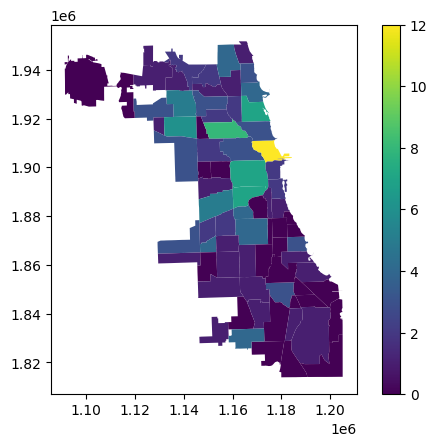

In [25]:
#create a choropleth plot
community_groceries.plot(column="size", legend=True)

### Nearest joins

Proximity-based joins can be done via `GeoDataFrame.sjoin_nearest()`. `GeoDataFrame.sjoin_nearest()` shares the how argument with `GeoDataFrame.sjoin()`, and includes two additional arguments: __max_distance__ and __distance_col__:

* _max_distance_: The max_distance argument specifies a maximum search radius for matching geometries. This can have a considerable performance impact in some cases. If you can, it is highly recommended that you use this parameter.
* _distance_col_: If set, the resultant GeoDataFrame will include a column with this name containing the computed distances between an input geometry and the nearest geometry.

### Buffers

A **buffer** creates a new polygon around a geometry at a specified distance. 
This is useful for proximity analysis — for example, finding everything within 1 km of a point.

Note: the buffer distance must be in the same units as the CRS. 
Our Chicago data uses US survey feet, so we need to convert from meters.

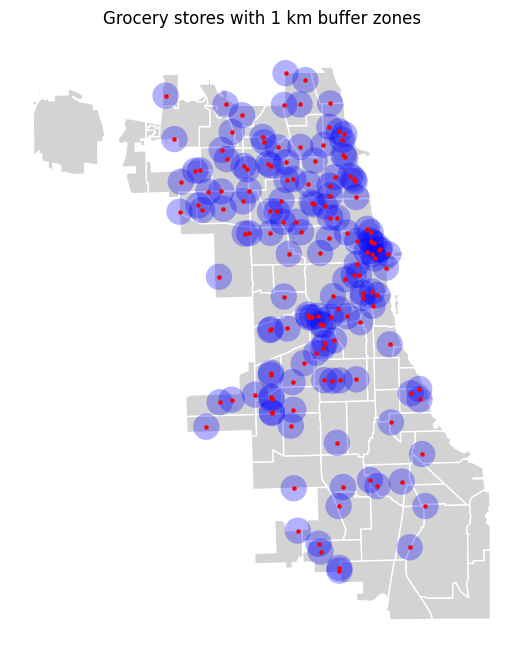

In [26]:
# Create a 1 km buffer around each grocery store
# CRS is in US survey feet, so convert: 1 km = 1000 m / 0.3048006 ft/m
buffer_distance = 1000 / 0.3048006

grocery_buffers = groceries.copy()
grocery_buffers['geometry'] = groceries.geometry.buffer(buffer_distance)

# Plot: original points and their 1 km buffers
f, ax = plt.subplots(1, figsize=(8, 8))
chicago.plot(ax=ax, color='lightgrey', edgecolor='white')
grocery_buffers.plot(ax=ax, alpha=0.3, color='blue')
groceries.plot(ax=ax, color='red', markersize=5)
ax.set_title('Grocery stores with 1 km buffer zones')
ax.set_axis_off();

# Part c) Kernel density estimation

**Kernel Density Estimation (KDE)** converts a point cloud into a smooth density surface.

Why not just use a point map? → Overlapping points obscure patterns in dense areas.

Useful for:
- **Urban planning**: where are accidents concentrated?
- **Public health**: where are disease cases clustering?
- **Business**: where is foot traffic highest?
- **Criminology**: which areas have the highest incident density?

We continue with the Chicago grocery store data from Part b). Instead of just showing where individual stores are located, we want to estimate the *density* of grocery access across the entire city.

### 1. Extract the coordinates of the grocery stores

In [27]:
# Initialize lists to store x and y values
x_values = []
y_values = []

# Iterate through each row in the GeoDataFrame
for multipoint in groceries.geometry:
    # Ensure the geometry is indeed MultiPoint; if it's just a single Point, wrap it in a list
    points = list(multipoint.geoms) if hasattr(multipoint, "geoms") else [multipoint]
    
    # For each Point in the MultiPoint, extract x and y values
    for point in points:
        x_values.append(point.x)
        y_values.append(point.y)

# Optionally, convert the lists to numpy arrays for further processing
x_values = np.array(x_values)
y_values = np.array(y_values)

### 2. Compute the kernel density estimation

In [28]:
from scipy.stats import gaussian_kde

# Rearrange data to create a 2D array of x and y coordinates
xy = np.vstack([x_values,y_values])

# Compute the density estimation
kde = gaussian_kde(xy)

# Define the grid points where you want to calculate the density
xmin, xmax = x_values.min(), x_values.max()
ymin, ymax = y_values.min(), y_values.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j] #generate 100 evenly spaced points between min and max

# Evaluate the density at grid points
density = kde(np.vstack([xx.ravel(), yy.ravel()]))
density = density.reshape(xx.shape) # reshape to the original shape of xx (for plotting)

### 3. Plot the results

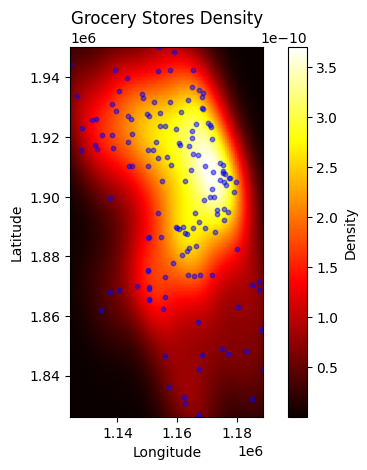

In [29]:
plt.imshow(np.rot90(density), cmap='hot', extent=[xmin, xmax, ymin, ymax])
plt.colorbar(label='Density')
plt.scatter(x_values, y_values, s=10, c='blue', alpha=0.5)
plt.title('Grocery Stores Density')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## KDE Plot using the 'seaborn' package

If you only want to create a kernel density plot, you can use the `kdeplot()` function of the  `seaborn` package:

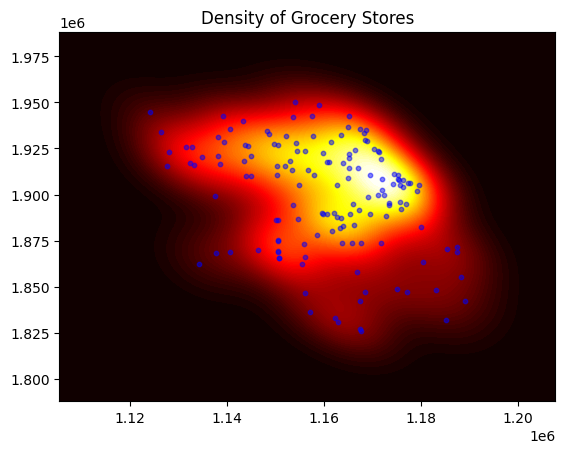

In [30]:
seaborn.kdeplot(x = x_values, y=y_values, fill=True, thresh=0, levels=100, cmap="hot")
plt.scatter(x_values, y_values, s=10, c='blue', alpha=0.5)
plt.title('Density of Grocery Stores')
plt.show()

## Practice Tasks

### Task 1: Fix the Map

Run the code below. It produces a choropleth map of grocery store counts per community in Chicago. Imagine a city official presents this map and argues: *"The south side of Chicago has adequate grocery access — several communities there have just as many stores as the north side."*

**Your task:**
1. What is misleading about using this map to draw conclusions about grocery access?
2. Create an improved version of the map that allows for a fairer comparison between communities.

<Axes: >

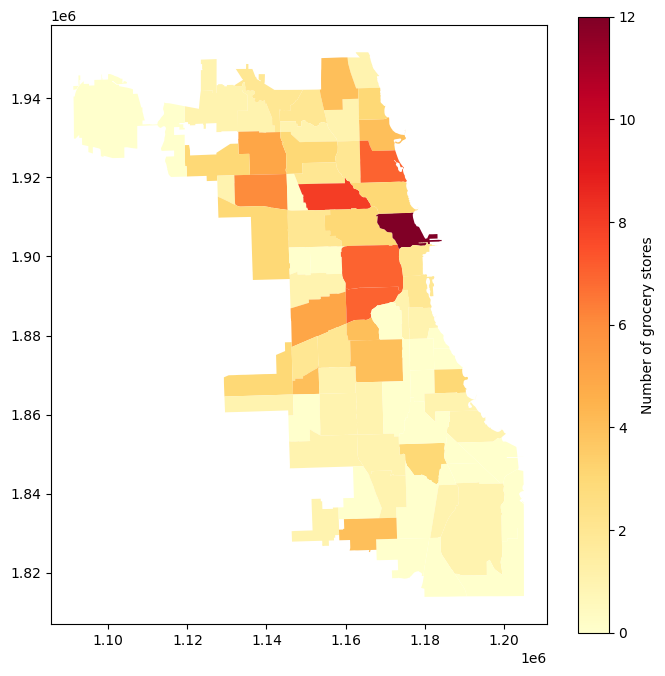

In [31]:
community_groceries.plot(column="size", legend=True, figsize=(8, 8),
                         cmap="YlOrRd",
                         legend_kwds={"label": "Number of grocery stores"})

*Your answer: What is misleading about this map?*


In [32]:
#Eine Community mit 10 Läden wirkt „gut versorgt“, aber wenn dort 80 000 Menschen leben, ist das schlechter als eine Community mit 5 Läden und 10 000 Einwohnern.
#Kurz gesagt:
#Die Karte vergleicht absolute Zahlen, obwohl die Communities nicht vergleichbar sind.

import matplotlib.pyplot as plt

# Neue Kennzahl: Läden pro 10.000 Einwohner
community_groceries["stores_per_10k"] = (
    community_groceries["Size"] / community_groceries["Population"] * 10000
)

# Karte zeichnen
community_groceries.plot(
    column="stores_per_10k",
    legend=True,
    figsize=(8, 8),
    cmap="YlGnBu",
    legend_kwds={"label": "Grocery stores per 10,000 residents"}
)

plt.title("Grocery Access in Chicago (Population‑Adjusted)")
plt.axis("off")
plt.show()


KeyError: 'Size'

### Task 2: Food Deserts

A food policy researcher defines a community as a **food desert** if no grocery store is within 1 km of its boundary.

**Your task:**
1. Think about which spatial operations you need to answer this question.
2. Identify which Chicago communities are food deserts under this definition.

*Hint: Consider using a buffer around the grocery store locations and then a spatial join.*

In [ ]:
# Your code here


### Task 3: What Went Wrong?

A colleague created two KDE plots of the grocery store locations in Chicago. Run the code below to see the results.

**Your task:**
1. Describe what you see in each plot. Which features of the data are visible, and which are hidden?
2. Explain what is wrong with each plot and why.
3. Create an improved version.

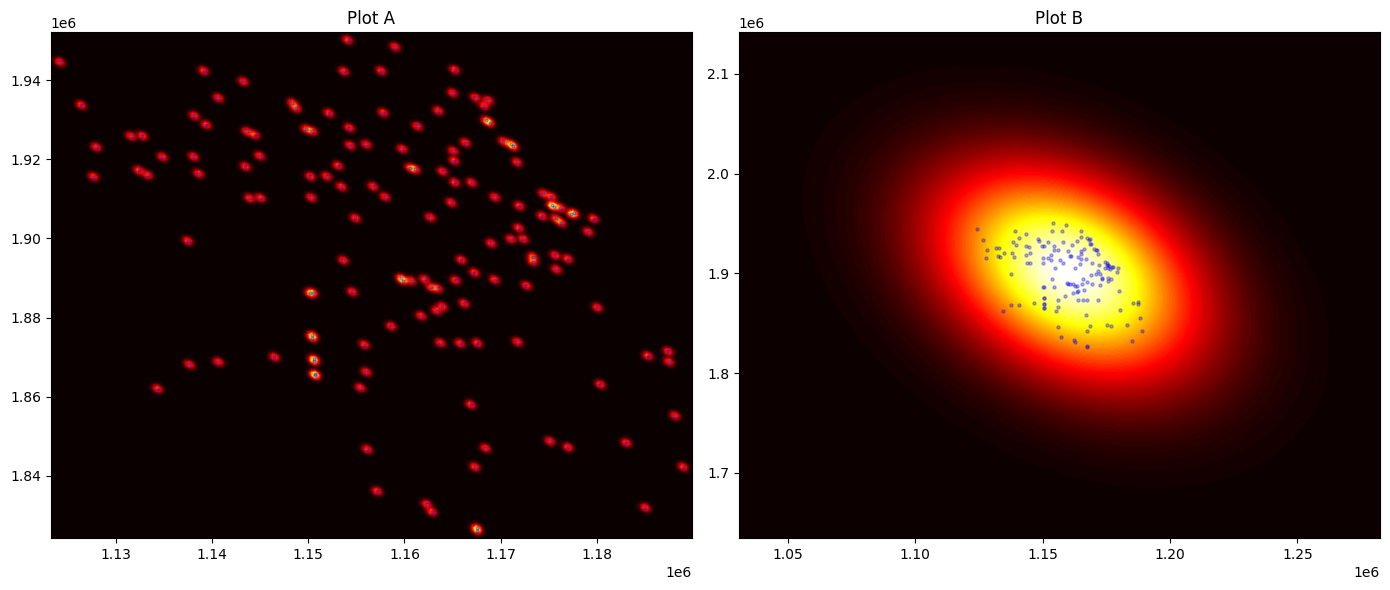

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot A
seaborn.kdeplot(x=x_values, y=y_values, fill=True, thresh=0, levels=100,
                cmap='hot', bw_adjust=0.05, ax=axes[0])
axes[0].scatter(x_values, y_values, s=5, c='blue', alpha=0.3)
axes[0].set_title('Plot A')

# Plot B
seaborn.kdeplot(x=x_values, y=y_values, fill=True, thresh=0, levels=100,
                cmap='hot', bw_adjust=5.0, ax=axes[1])
axes[1].scatter(x_values, y_values, s=5, c='blue', alpha=0.3)
axes[1].set_title('Plot B')

plt.tight_layout()

*Your answer here*


In [ ]:
# Your plot with a better bandwidth here


## Further resources


### Spatial Operations

More advanced GIS operations are possible in `geopandas` and, in most cases, they are extensions of the same logic we have used in this document. If you are thinking about taking the next step from here, the following operations (and the documentation provided) will give you the biggest ["bang for the buck"](https://en.wikipedia.org/wiki/Bang_for_the_buck):


* **Spatial overlays**: create new shapes based on places where two datasets overlap (or don’t overlap)

> [https://geopandas.org/set_operations.html](https://geopandas.org/set_operations.html)

### Creating Maps

* **[Geoplot](https://residentmario.github.io/geoplot/index.html)** is a great python package for making spatial plots (going beyond of what we covered)

* **[Kepler](https://kepler.gl/)** is a great tool to quickly create and explore maps via drag-and-drop

### Kernel Density Estimation

* **[The Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/05.13-kernel-density-estimation.html)** has a great section on KDE, including on how to set and tune kernel bandwiths

<img src="images/d3.png" style="width:50%; float:center;" />